DCGAN train loop

In [4]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses, metrics

IMAGE_SIZE = 128
CHANNELS = 3
BATCH_SIZE = 64          
Z_DIM = 100
EPOCHS = 5 #starting with 5 epochs            
LOAD_MODEL = False

ADAM_BETA_1 = 0.5
ADAM_BETA_2 = 0.999
LEARNING_RATE = 0.0002 
NOISE_PARAM = 0.1        

DATA_ROOT = "fish-dataset"  

In [5]:
def make_dataset():
    ds = keras.utils.image_dataset_from_directory(
        DATA_ROOT,
        label_mode=None,
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42,
    )
    
    #uint8 [0,255] → [-1, 1]
    norm = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0)
    ds = ds.map(lambda x: norm(tf.cast(x, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset()

Found 3983 files.


generator: 128x128x3 

In [7]:
NGF = 64  #base width

def build_generator(z_dim=Z_DIM, ngf=NGF):
    inp = layers.Input(shape=(z_dim,))
    x = layers.Reshape((1, 1, z_dim))(inp)

    # 1×1×z_dim → 4×4×(ngf*8)
    x = layers.Conv2DTranspose(ngf * 8, 4, strides=1, padding="valid", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf * 4, 4, strides=2, padding="same", use_bias=False)(x)  # 8×8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf * 2, 4, strides=2, padding="same", use_bias=False)(x)  # 16×16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf, 4, strides=2, padding="same", use_bias=False)(x)      # 32×32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2DTranspose(ngf // 2, 4, strides=2, padding="same", use_bias=False)(x)   # 64×64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    out = layers.Conv2DTranspose(
        CHANNELS, 4, strides=2, padding="same", use_bias=False, activation="tanh"
    )(x)   # 128×128×3

    return models.Model(inp, out, name="generator")

generator = build_generator()

discriminator 

In [8]:
NDF = 64

def build_discriminator(img_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), ndf=NDF):
    inp = layers.Input(shape=img_shape)

    # 128 → 64 , no BN on first conv
    x = layers.Conv2D(ndf, 4, strides=2, padding="same", use_bias=False)(inp)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 2, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 4, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 8, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(ndf * 8, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # 4×4 → 1 logit per image
    x = layers.Conv2D(1, 4, strides=1, padding="valid", use_bias=False)(x)
    out = layers.Flatten()(x)

    return models.Model(inp, out, name="discriminator")

discriminator = build_discriminator()

In [9]:
class DCGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.loss_fn = losses.BinaryCrossentropy(from_logits=True)

    def compile(self, d_optimizer, g_optimizer):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.d_loss_metric = metrics.Mean(name="d_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        if isinstance(real_images, tuple):
            real_images = real_images[0]

        batch_size = tf.shape(real_images)[0]

        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(random_latent_vectors, training=True)

            real_predictions = self.discriminator(real_images, training=True)
            fake_predictions = self.discriminator(generated_images, training=True)

            real_labels = tf.ones_like(real_predictions)
            fake_labels = tf.zeros_like(fake_predictions)

            real_noisy_labels = real_labels + NOISE_PARAM * tf.random.uniform(
                tf.shape(real_predictions), 0.0, 1.0
            )
            fake_noisy_labels = fake_labels - NOISE_PARAM * tf.random.uniform(
                tf.shape(fake_predictions), 0.0, 1.0
            )

            d_real_loss = self.loss_fn(real_noisy_labels, real_predictions)
            d_fake_loss = self.loss_fn(fake_noisy_labels, fake_predictions)
            d_loss = (d_real_loss + d_fake_loss) / 2.0

            # Generator tries to make fakes classified as real
            g_loss = self.loss_fn(tf.ones_like(fake_predictions), fake_predictions)

        grad_d = disc_tape.gradient(d_loss, self.discriminator.trainable_variables)
        grad_g = gen_tape.gradient(g_loss, self.generator.trainable_variables)

        self.d_optimizer.apply_gradients(zip(grad_d, self.discriminator.trainable_variables))
        self.g_optimizer.apply_gradients(zip(grad_g, self.generator.trainable_variables))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {m.name: m.result() for m in self.metrics}


dcgan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=Z_DIM)

dcgan.compile(
    d_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
    g_optimizer=optimizers.Adam(
        learning_rate=LEARNING_RATE, beta_1=ADAM_BETA_1, beta_2=ADAM_BETA_2
    ),
)

In [10]:
if LOAD_MODEL:
    generator.load_weights(os.path.join("checkpoints_keras", "g.weights.h5"))
    discriminator.load_weights(os.path.join("checkpoints_keras", "d.weights.h5"))

history = dcgan.fit(train_ds, epochs=EPOCHS)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - d_loss: -2.3275 - g_loss: 46.0658
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - d_loss: -6.3927 - g_loss: 126.7384
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - d_loss: -7.7330 - g_loss: 192.0894
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - d_loss: 1.5060 - g_loss: 21.9983
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - d_loss: -0.2274 - g_loss: 22.7535


In [11]:
OUT_DIR = "outputs_keras"
CKPT_DIR = "checkpoints_keras"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

generator.save_weights(os.path.join(CKPT_DIR, "generator.weights.h5"))
discriminator.save_weights(os.path.join(CKPT_DIR, "discriminator.weights.h5"))
print("Saved weights to", CKPT_DIR)

Saved weights to checkpoints_keras


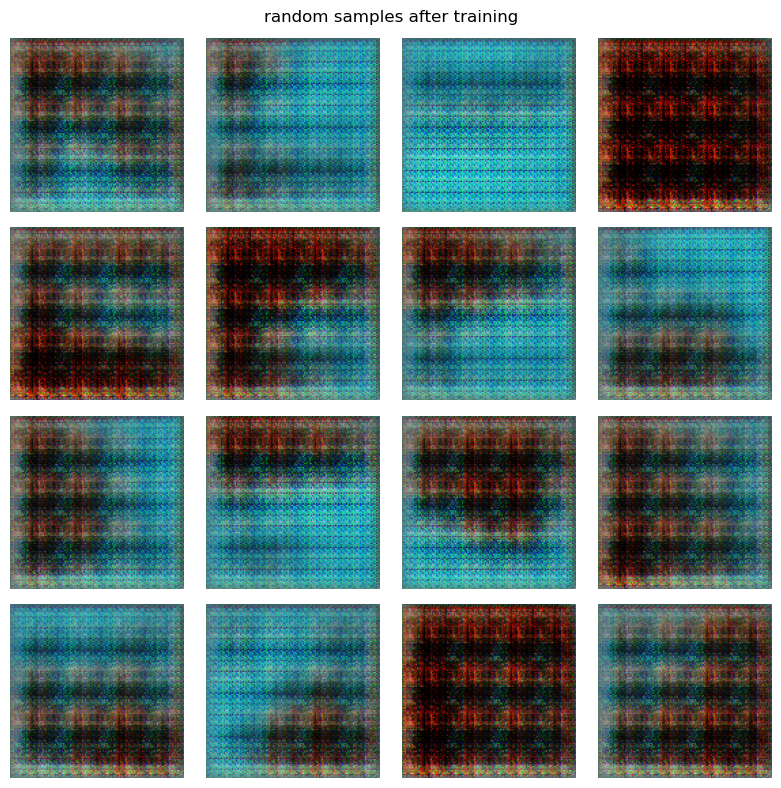

In [13]:
import matplotlib.pyplot as plt

def denorm_to_01(x):
    return (x + 1.0) / 2.0

n_show = 16
z_sample = tf.random.normal(shape=(n_show, Z_DIM))
fake = generator(z_sample, training=False)
fake_01 = tf.clip_by_value(denorm_to_01(fake), 0.0, 1.0)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_01[i].numpy())
    ax.axis("off")
plt.suptitle("random samples after training")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "samples_grid.png"), dpi=150)
plt.show()